In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import sys
from pathlib import Path
from src.run_model import run_analysis
from src.config import CSV_PATH
from src.preprocess import load_and_prep_data


================ CLUSTERING SANITY CHECK ================
Regime: controlled
Features used: ['PBEAM_TOT', 'BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'NES']
Silhouette Score: 0.404
 -> Assessment: Fair structure; expected overlap across continuous plasma regimes.

Cluster Size Balance:
  Cluster 0: 332 shots (33.2%)
  Cluster 1: 373 shots (37.3%)
  Cluster 2: 161 shots (16.1%)
  Cluster 3: 133 shots (13.3%)

--- Cluster Means ---
               PBEAM_TOT       BZXR   PBEAM_A   PBEAM_B   PBEAM_C           NES      ETAU
Cluster_Label                                                                            
2               3.477672  37.583082 -0.000366  1.961619  1.516418  5.724205e+13  0.045923
1               4.149743  39.533137  1.948345  1.991352  0.210047  6.559004e+13  0.042155
0               5.583279  38.393384  1.962578  1.790524  1.830177  7.893287e+13  0.037482
3               2.004975  42.550452  1.489082  0.086901  0.428992  4.498990e+13  0.036148


/Users/aldensantoso/Documents/plasma_research/ML Project/src/run_model.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")


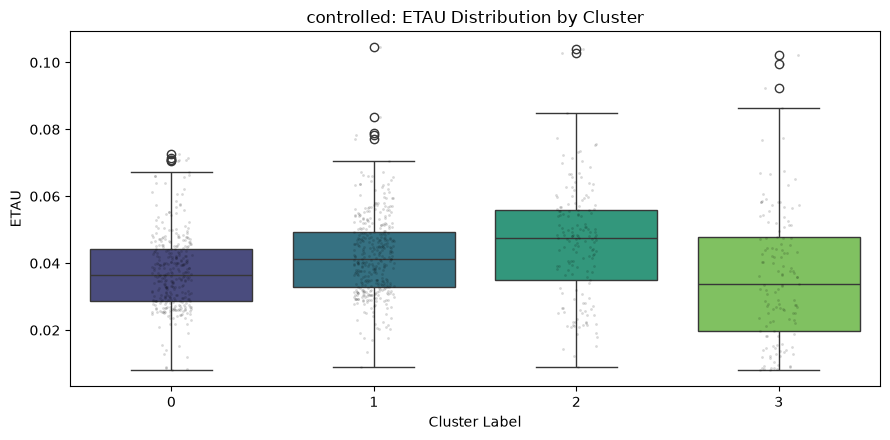


ETAU prediction using KMeans clusters: R^2 = 0.650
ETAU prediction using KMeans clusters: RMSE = 0.008


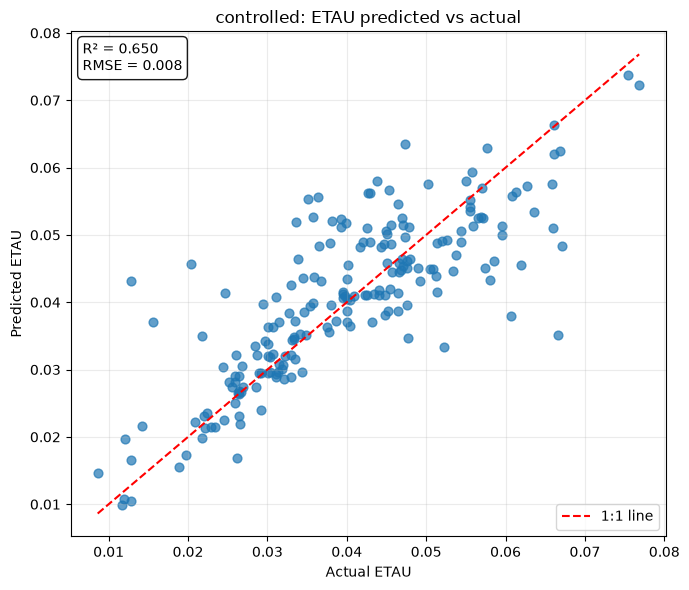

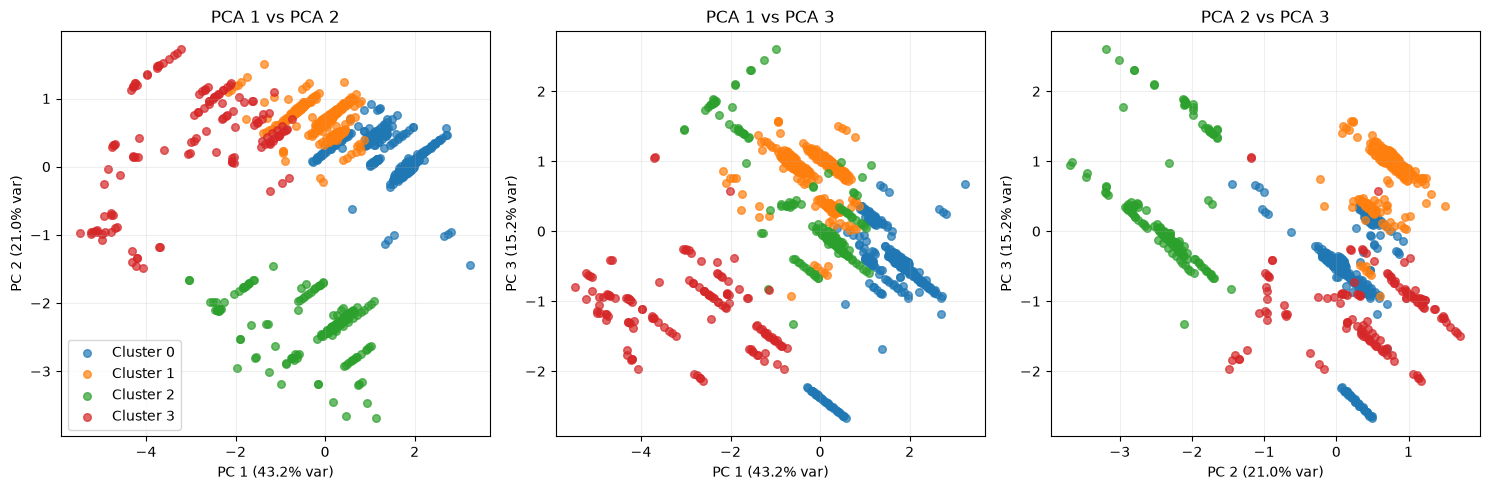

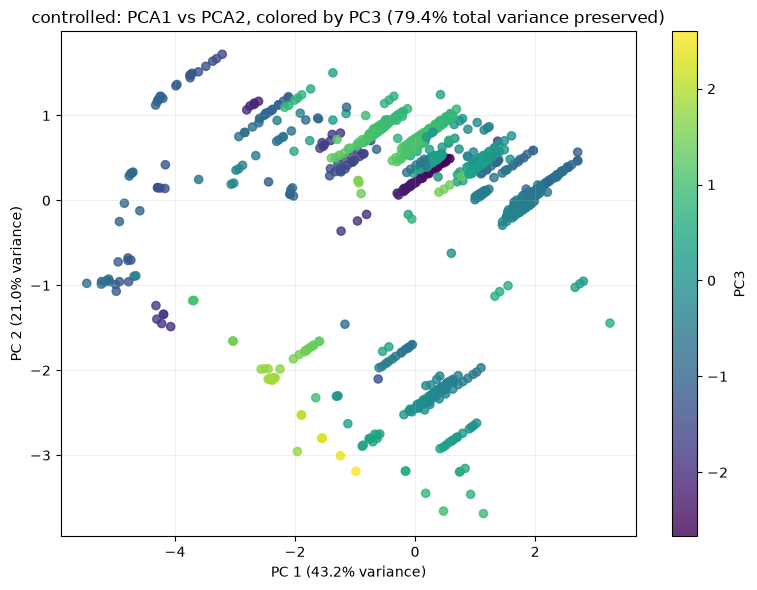


PCA component loadings:
     PBEAM_TOT      BZXR   PBEAM_A   PBEAM_B   PBEAM_C       NES
PC1   0.576492 -0.380970  0.191605  0.394523  0.377011  0.433614
PC2   0.119087  0.298761  0.812328 -0.120882 -0.417629  0.218307
PC3  -0.054168 -0.237802 -0.059785  0.710250 -0.620828 -0.216931
================ CLUSTERING SANITY CHECK ================
Regime: secondary
Features used: ['PBEAM_TOT', 'BZXR', 'TE', 'VBEAM_A', 'VBEAM_B', 'VBEAM_C']
Silhouette Score: 0.417
 -> Assessment: Fair structure; expected overlap across continuous plasma regimes.

Cluster Size Balance:
  Cluster 0: 304 shots (30.4%)
  Cluster 1: 161 shots (16.1%)
  Cluster 2: 367 shots (36.7%)
  Cluster 3: 167 shots (16.7%)

--- Cluster Means ---
               PBEAM_TOT       BZXR          TE    VBEAM_A    VBEAM_B    VBEAM_C      ETAU
Cluster_Label                                                                             
1               3.477672  37.583082  943.181135  -0.049642  89.248340  71.419399  0.045923
0            

/Users/aldensantoso/Documents/plasma_research/ML Project/src/run_model.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")


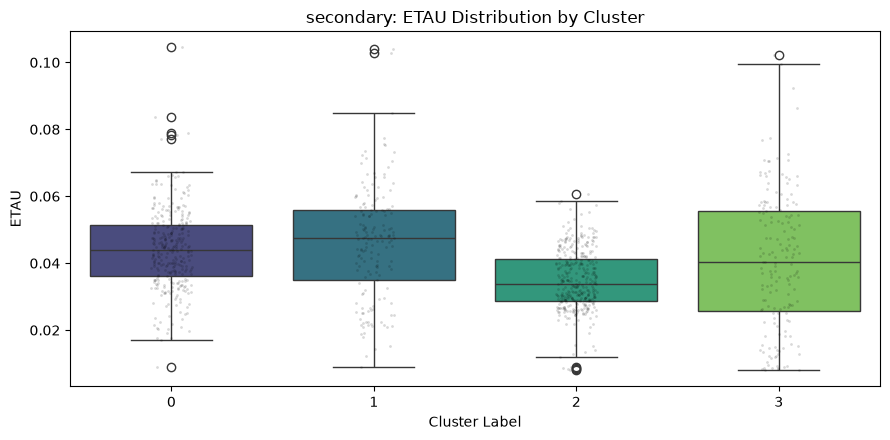


ETAU prediction using KMeans clusters: R^2 = 0.706
ETAU prediction using KMeans clusters: RMSE = 0.007


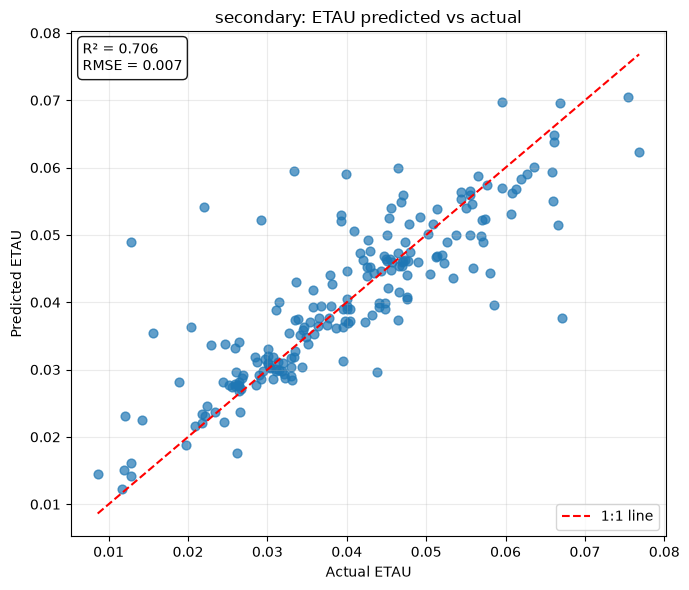

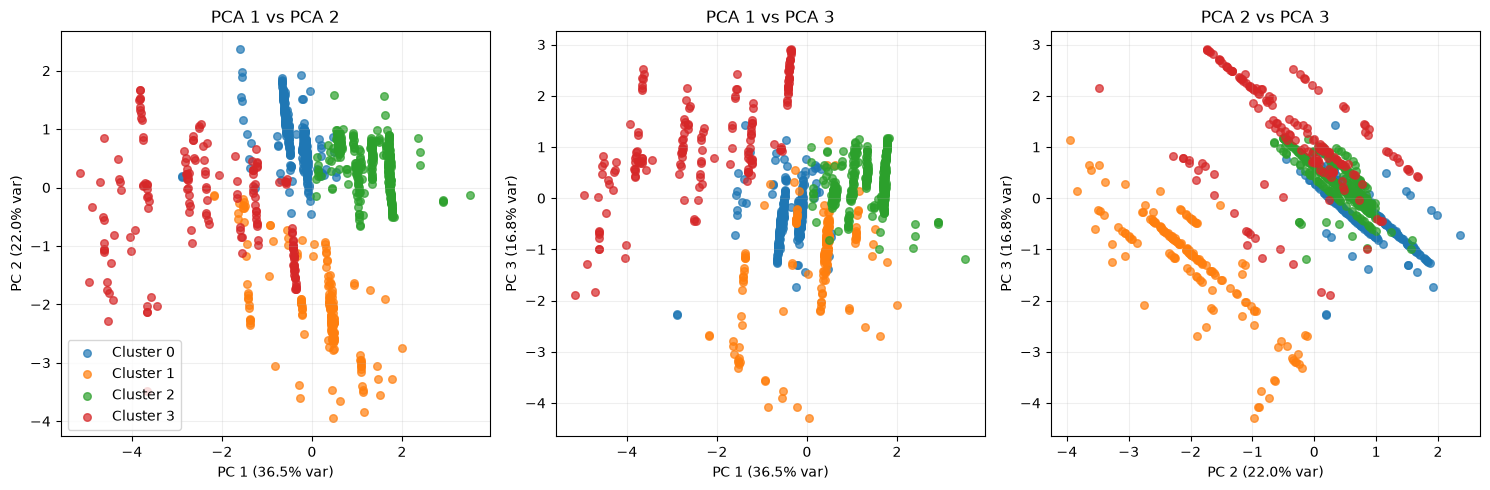

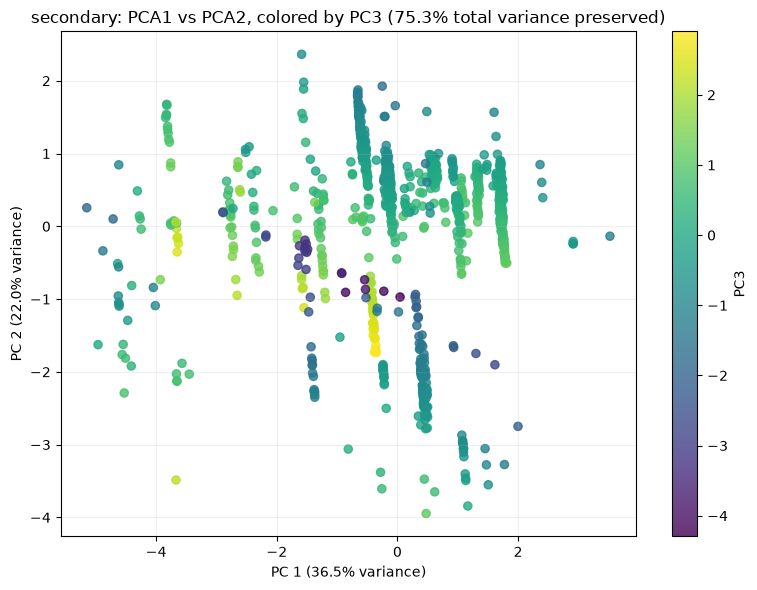


PCA component loadings:
     PBEAM_TOT      BZXR        TE   VBEAM_A   VBEAM_B   VBEAM_C
PC1   0.629139 -0.430914  0.048426  0.134475  0.465985  0.425355
PC2   0.206538  0.213726 -0.509633  0.695688  0.126739 -0.389733
PC3   0.202243  0.240538  0.535053  0.513785 -0.517594  0.288234


In [2]:

controlled_features = [
    "PBEAM_TOT",
    "BZXR",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
    "NES",
]

mode_features = [
    "PBEAM_TOT",
    "BZXR",
    "TE",
    "VBEAM_A",
    "VBEAM_B",
    "VBEAM_C",
]

analysis_control = run_analysis(
    feature_cols=controlled_features,
    regime_name="controlled",
)

analysis_secondary = run_analysis(
    feature_cols=mode_features,
    regime_name="secondary",
)

In [3]:
# Cell 1: load and prepare only the controlled variables


PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

controlled_features = [
    "PBEAM_TOT",
    "BZXR",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
    "NES"
]

df_clean_controlled = load_and_prep_data(
    str(CSV_PATH),
    feature_cols=controlled_features,
)

print("Rows:", len(df_clean_controlled))
print("Controlled feature list:", controlled_features)
print("Target column:", "ETAU")

Rows: 1021
Controlled feature list: ['PBEAM_TOT', 'BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'NES']
Target column: ETAU


================ CLUSTERING SANITY CHECK ================
Regime: controlled
Features used: ['PBEAM_TOT', 'BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'NES']
Silhouette Score: 0.404
 -> Assessment: Fair structure; expected overlap across continuous plasma regimes.

Cluster Size Balance:
  Cluster 0: 332 shots (33.2%)
  Cluster 1: 373 shots (37.3%)
  Cluster 2: 161 shots (16.1%)
  Cluster 3: 133 shots (13.3%)

--- Cluster Means ---
               PBEAM_TOT       BZXR   PBEAM_A   PBEAM_B   PBEAM_C           NES      ETAU
Cluster_Label                                                                            
2               3.477672  37.583082 -0.000366  1.961619  1.516418  5.724205e+13  0.045923
1               4.149743  39.533137  1.948345  1.991352  0.210047  6.559004e+13  0.042155
0               5.583279  38.393384  1.962578  1.790524  1.830177  7.893287e+13  0.037482
3               2.004975  42.550452  1.489082  0.086901  0.428992  4.498990e+13  0.036148


/Users/aldensantoso/Documents/plasma_research/ML Project/src/run_model.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")


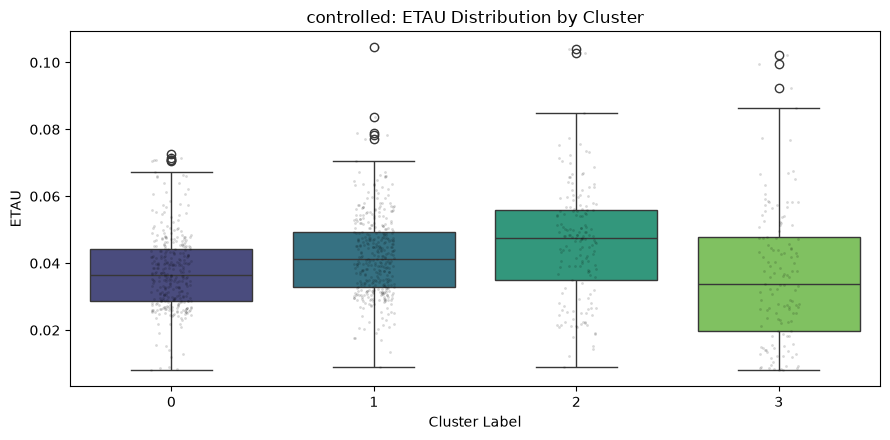


ETAU prediction using KMeans clusters: R^2 = 0.650
ETAU prediction using KMeans clusters: RMSE = 0.008


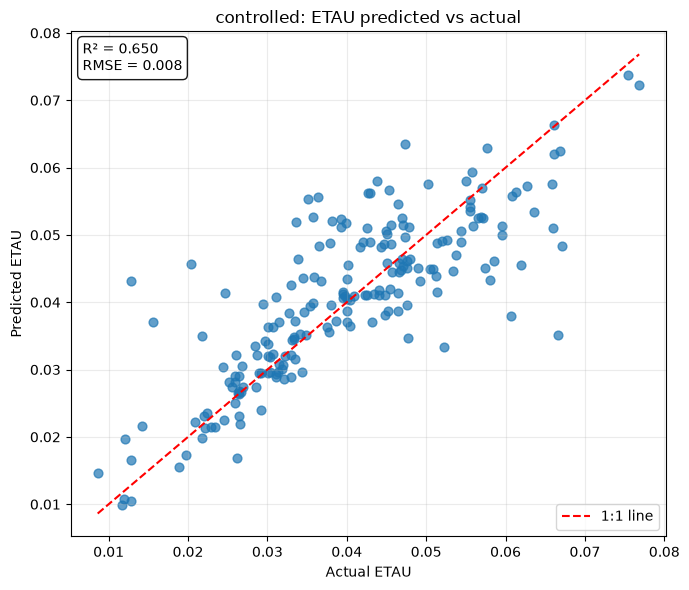

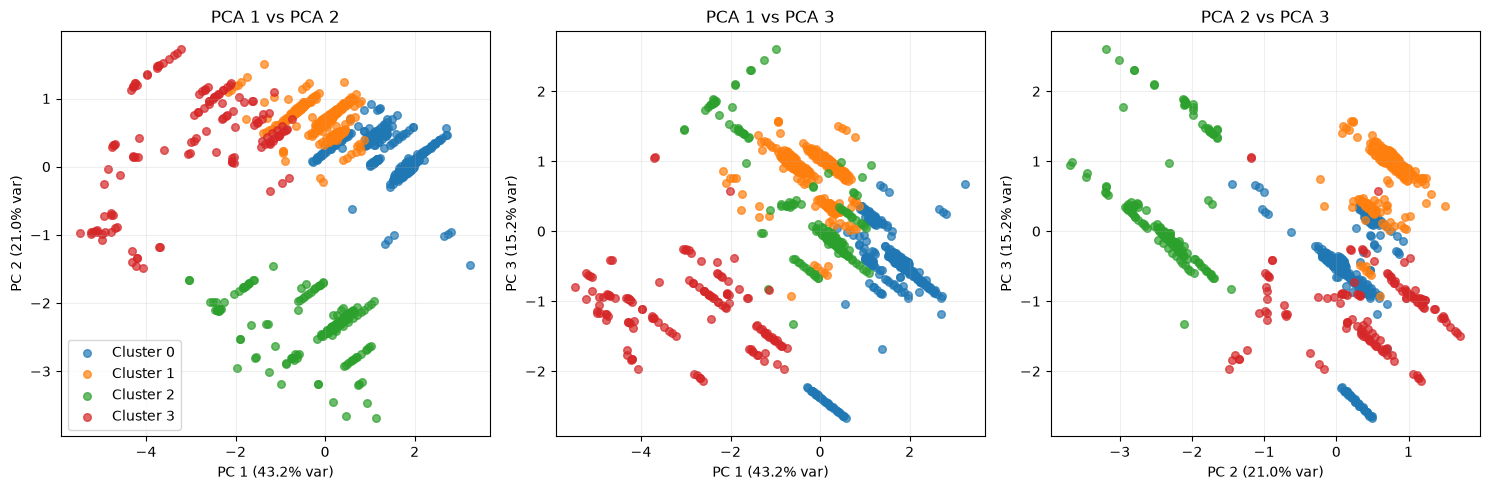

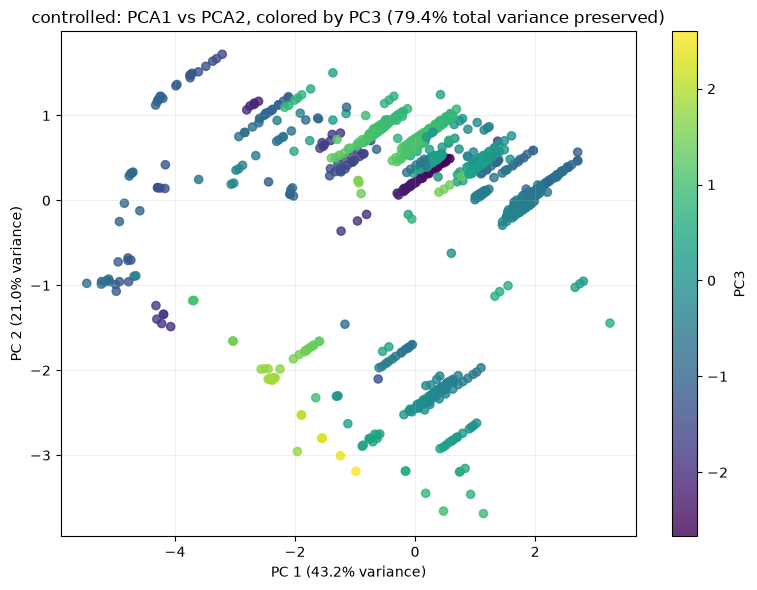


PCA component loadings:
     PBEAM_TOT      BZXR   PBEAM_A   PBEAM_B   PBEAM_C       NES
PC1   0.576492 -0.380970  0.191605  0.394523  0.377011  0.433614
PC2   0.119087  0.298761  0.812328 -0.120882 -0.417629  0.218307
PC3  -0.054168 -0.237802 -0.059785  0.710250 -0.620828 -0.216931
{'regime_name': 'controlled', 'target_col': 'ETAU', 'selected_features': ['PBEAM_TOT', 'BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'NES'], 'n_clusters': 4, 'silhouette_score': 0.4035286732438176, 'cluster_counts': {0: 332, 1: 373, 2: 161, 3: 133}, 'cluster_summary':                PBEAM_TOT       BZXR   PBEAM_A   PBEAM_B   PBEAM_C  \
Cluster_Label                                                       
2               3.477672  37.583082 -0.000366  1.961619  1.516418   
1               4.149743  39.533137  1.948345  1.991352  0.210047   
0               5.583279  38.393384  1.962578  1.790524  1.830177   
3               2.004975  42.550452  1.489082  0.086901  0.428992   

                        NES      ETA

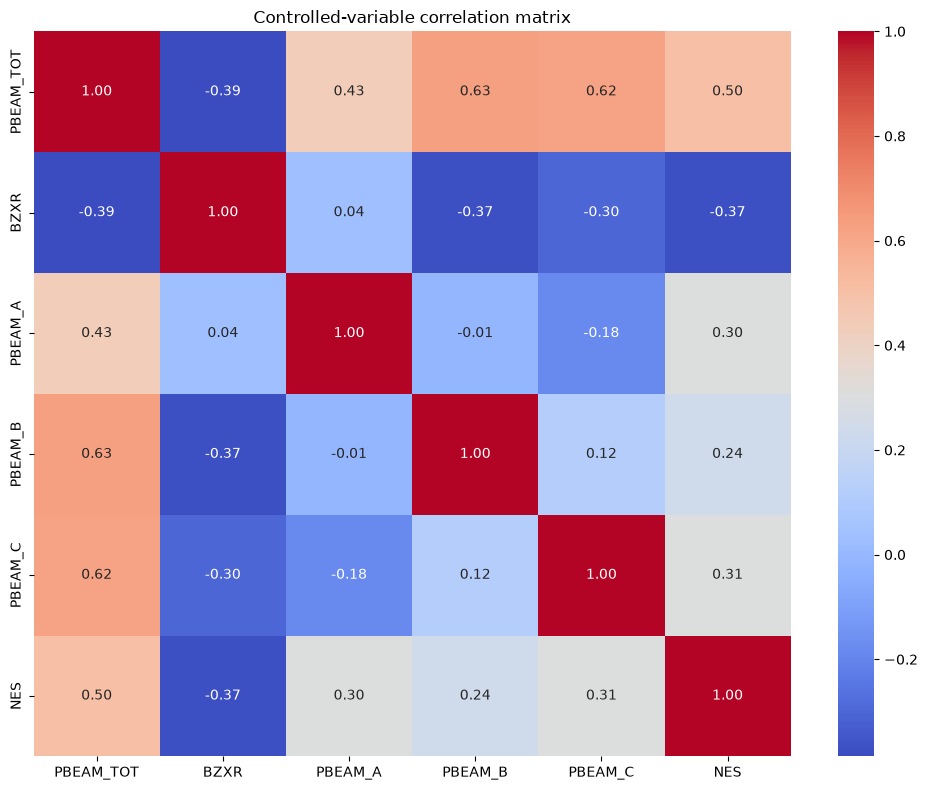

In [7]:
# Controlled regime
from src.run_model import run_analysis
from src.preprocess import plot_correlation_matrix

controlled_features = [
    "PBEAM_TOT",
    "BZXR",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
    "NES",
]

df_clean_controlled = load_and_prep_data(
    str(CSV_PATH),
    feature_cols=controlled_features,
)

analysis_controlled = run_analysis(
    feature_cols=controlled_features,
    regime_name="controlled",
    n_clusters=4,
)

print(analysis_controlled["report"])
print(analysis_controlled["cluster_summary"])

plot_correlation_matrix(
    df_clean_controlled,
    cols=controlled_features,
    title="Controlled-variable correlation matrix",
)

In [5]:
PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

mode_features = [
    "TOTPWR",
    "AVGMODEN",
    "AVGMODEF",
    "CONDE",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C"
]

target = ['ETAU']

df_clean_mode = load_and_prep_data(
    str(CSV_PATH),
    feature_cols=mode_features,
)

print("Rows:", len(df_clean_mode))
print("Controlled feature list:", mode_features)
print("Target column:", "ETAU")

Rows: 1021
Controlled feature list: ['TOTPWR', 'AVGMODEN', 'AVGMODEF', 'CONDE', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C']
Target column: ETAU


================ CLUSTERING SANITY CHECK ================
Regime: mode
Features used: ['TOTPWR', 'AVGMODEN', 'AVGMODEF', 'CONDE', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C']
Silhouette Score: 0.312
 -> Assessment: Fair structure; expected overlap across continuous plasma regimes.

Cluster Size Balance:
  Cluster 0: 161 shots (16.1%)
  Cluster 1: 306 shots (30.6%)
  Cluster 2: 369 shots (36.9%)
  Cluster 3: 163 shots (16.3%)

--- Cluster Means ---
                     TOTPWR  AVGMODEN    AVGMODEF         CONDE   PBEAM_A   PBEAM_B   PBEAM_C      ETAU
Cluster_Label                                                                                          
3              3.199933e-11 -1.323117  594.292150  1.236850e+07  0.011472  1.966910  1.510230  0.045768
2              1.771425e-11 -2.132680  544.594098  7.660829e+06  1.949952  1.996002  0.330818  0.042574
0              1.249643e-11 -0.599407  529.128412  1.068537e+07  1.681979  0.100785  0.799009  0.042195
1              2.963609e-11 -3.873371  6

/Users/aldensantoso/Documents/plasma_research/ML Project/src/run_model.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")


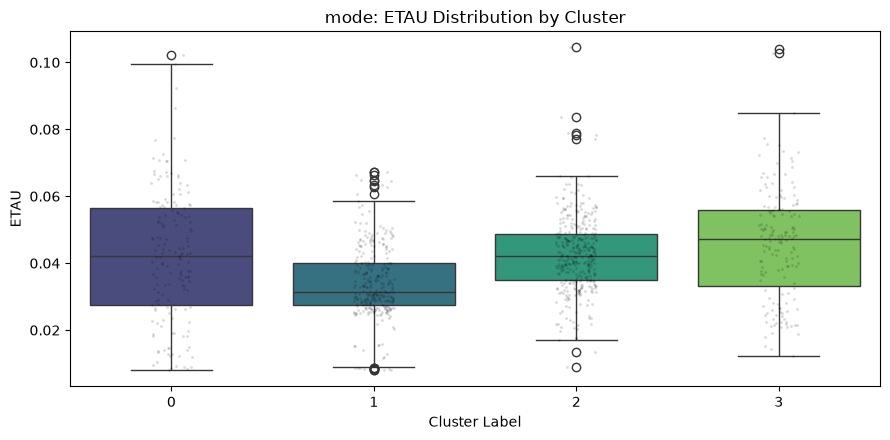


ETAU prediction using KMeans clusters: R^2 = 0.464
ETAU prediction using KMeans clusters: RMSE = 0.010


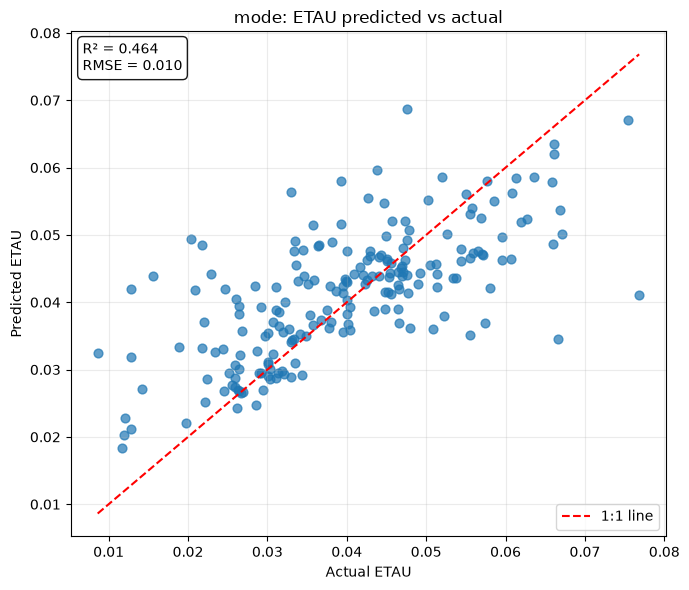

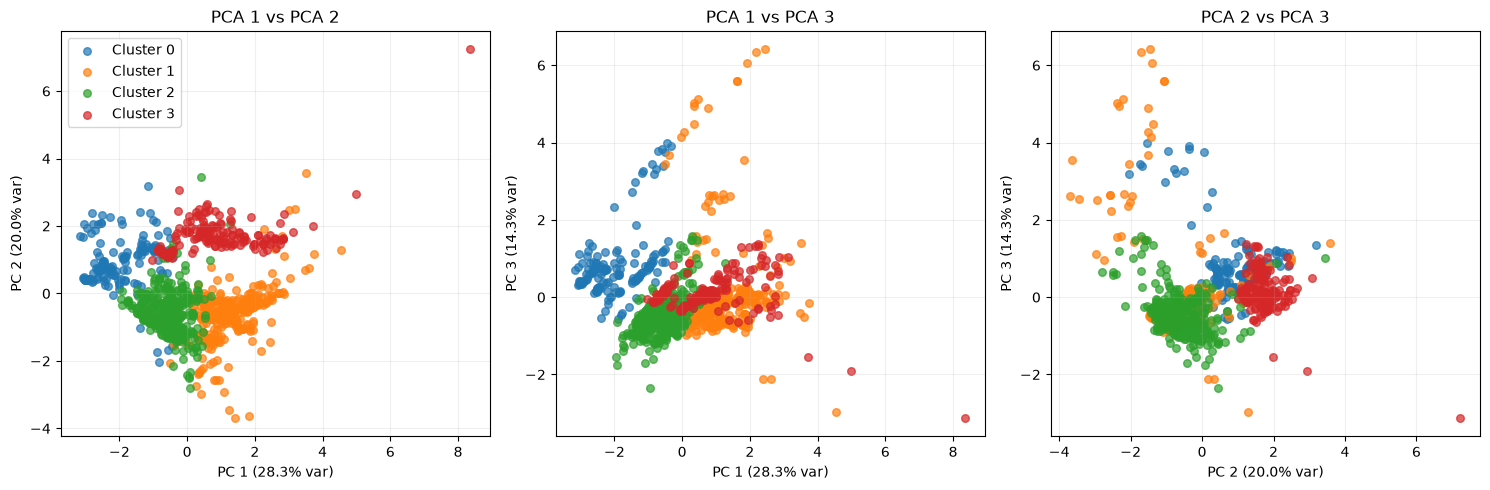

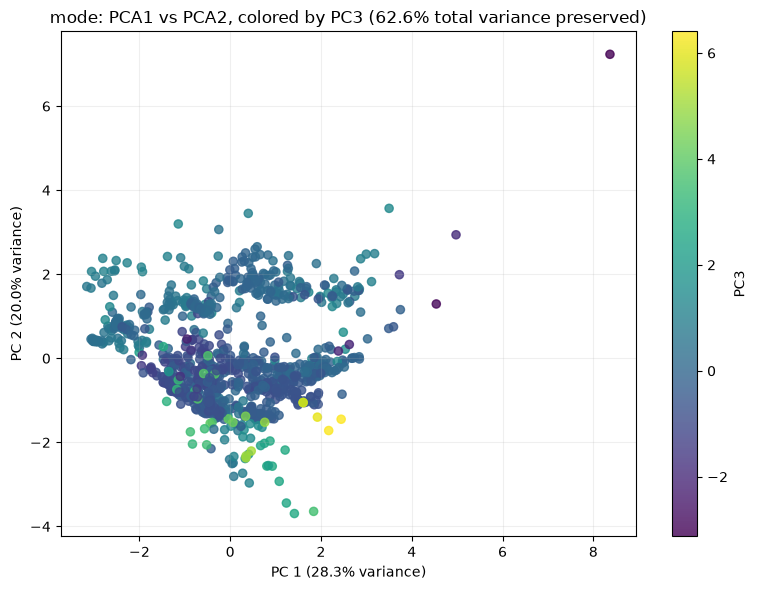


PCA component loadings:
       TOTPWR  AVGMODEN  AVGMODEF     CONDE   PBEAM_A   PBEAM_B   PBEAM_C
PC1  0.538238 -0.406969  0.411487  0.128995 -0.116674  0.399719  0.430496
PC2  0.246001  0.562086 -0.160313  0.389620 -0.537816 -0.226474  0.324810
PC3 -0.284359 -0.176516  0.708420  0.139771 -0.259381 -0.537592 -0.101502
{'regime_name': 'mode', 'target_col': 'ETAU', 'selected_features': ['TOTPWR', 'AVGMODEN', 'AVGMODEF', 'CONDE', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C'], 'n_clusters': 4, 'silhouette_score': 0.3117785457868513, 'cluster_counts': {0: 161, 1: 306, 2: 369, 3: 163}, 'cluster_summary':                      TOTPWR  AVGMODEN    AVGMODEF         CONDE   PBEAM_A  \
Cluster_Label                                                               
3              3.199933e-11 -1.323117  594.292150  1.236850e+07  0.011472   
2              1.771425e-11 -2.132680  544.594098  7.660829e+06  1.949952   
0              1.249643e-11 -0.599407  529.128412  1.068537e+07  1.681979   
1              2.9636

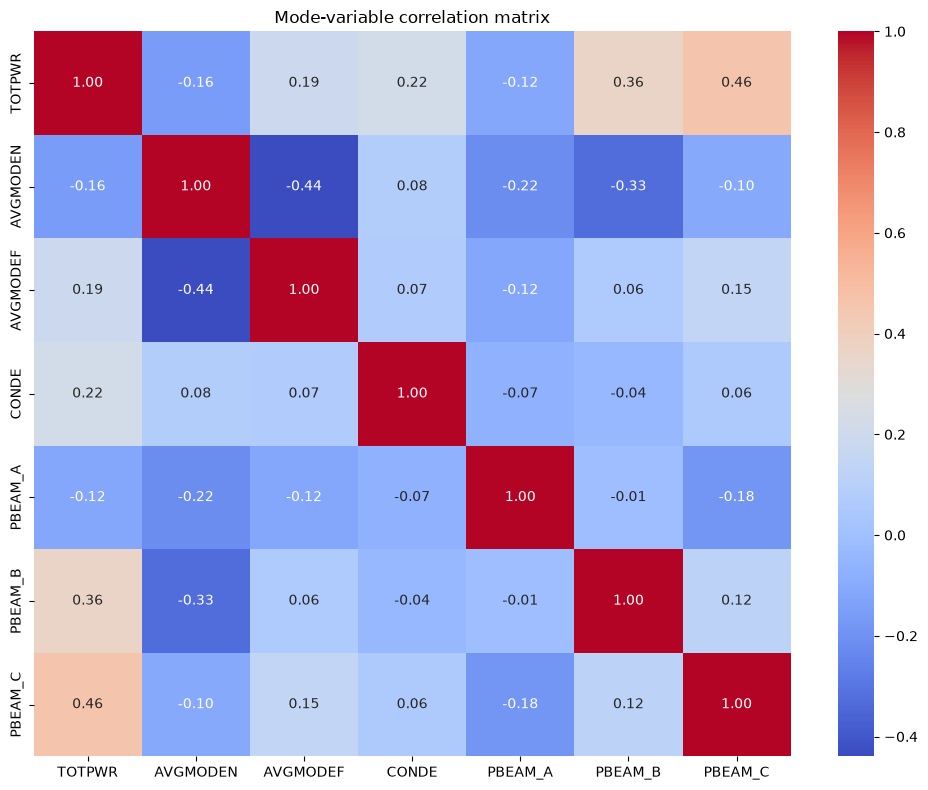

In [8]:
# Mode regime
from src.run_model import run_analysis
from src.preprocess import plot_correlation_matrix

mode_features = [
    "TOTPWR",
    "AVGMODEN",
    "AVGMODEF",
    "CONDE",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
]

df_clean_mode = load_and_prep_data(
    str(CSV_PATH),
    feature_cols=mode_features,
)

analysis_mode = run_analysis(
    feature_cols=mode_features,
    regime_name="mode",
    n_clusters=4,
)

print(analysis_mode["report"])
print(analysis_mode["cluster_summary"])

plot_correlation_matrix(
    df_clean_mode,
    cols=mode_features,
    title="Mode-variable correlation matrix",
)